In [1]:
# загрузим необходимые пакеты
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
from scipy.stats import binomtest
from scipy.stats import ttest_ind

In [2]:
# загрузим таблицу в датафрейм
df = pd.read_csv('hw_ab.csv')

In [3]:
# убеждаемся,что пользователи уникальные
print('Всего строк:', len(df))
print('Уникальных id:', df['id'].nunique())

Всего строк: 94778
Уникальных id: 94778


In [4]:
# проверяем, что пользователей в тесте и контроле приблизительно равное количество
df['group'].value_counts()

group
test       47448
control    47330
Name: count, dtype: int64

In [5]:
# определяем медианное значение в тесте и в контроле
df.groupby('group')['converted'].mean()

group
control    0.103993
test       0.119584
Name: converted, dtype: float64

In [6]:
# находим число открытых карт в тесте
conversions_test = df[df['group'] == 'test']['converted'].sum()
# находим общее число наблюдений в тесте
n_test = df[df['group'] == 'test']['converted'].count()
# нахоим число открытых карт в контроле
conversions_control = df[df['group'] == 'control']['converted'].sum()
# находим общее число наблюдений в контроле
n_control = df[df['group'] == 'control']['converted'].count()
# выводим результаты
print('Тест: карт открыто:', conversions_test, '| всего заходов:', n_test)
print('Контроль: карт открыто:', conversions_control, '| всего заходов:', n_control)

Тест: карт открыто: 5674 | всего заходов: 47448
Контроль: карт открыто: 4922 | всего заходов: 47330


In [7]:
# находим конверсию в каждой группе
conv_test = conversions_test / n_test
conv_control = conversions_control / n_control
# находим отношение конверсий
lift = (conv_test / conv_control)-1
# выводим результаты
print('Конверсия в тесте:', round(conv_test, 4))
print('Конверсия в контроле:', round(conv_control, 4))
print('Отношение конверсий (lift):', round(lift, 4))

Конверсия в тесте: 0.1196
Конверсия в контроле: 0.104
Отношение конверсий (lift): 0.1499


In [8]:
# используем статистический тест
result = binomtest(
    k=conversions_control,    # число успехов в контроле
    n=n_control,              # число наблюдений в контроле
    p=conv_test,              # ожидаемая вероятность (конверсия теста)
    alternative='two-sided'   # двусторонний тест
)
print('P-value:', round(result.pvalue, 6))

P-value: 0.0


In [9]:
# находим количество дней теста
print('Количество дней:', df['date'].nunique())
# находим список всех дат
dates = pd.to_datetime(df['date']).sort_values().unique()
# проверяем пропуски — разница между соседними датами должна быть 1 день
gaps = pd.Series(dates).diff().dropna()
print('Пропуски в датах:', (gaps != pd.Timedelta('1 days')).sum())
print('Начало:', dates[0])
print('Конец:', dates[-1])

Количество дней: 93
Пропуски в датах: 0
Начало: 2023-08-01 00:00:00
Конец: 2023-11-01 00:00:00


In [10]:
# считаем количество открытых карт и средние конверсии по дням в тесте и в контроле
daily_stats = df.groupby(['date', 'group'])['converted'].agg(
    открытых_карт='sum',
    заходов='count',
    конверсия='mean'
).reset_index()

print(daily_stats)

           date    group  открытых_карт  заходов  конверсия
0    2023-08-01  control             45      512   0.087891
1    2023-08-01     test             63      513   0.122807
2    2023-08-02  control             63      512   0.123047
3    2023-08-02     test             58      508   0.114173
4    2023-08-03  control             60      547   0.109689
..          ...      ...            ...      ...        ...
181  2023-10-30     test             58      480   0.120833
182  2023-10-31  control             54      507   0.106509
183  2023-10-31     test             68      508   0.133858
184  2023-11-01  control             49      528   0.092803
185  2023-11-01     test             49      525   0.093333

[186 rows x 5 columns]


In [11]:
# считаем конверсию из посещений в оформленние карт по дням
daily_conversion = df.groupby(['date', 'group'])['converted'].mean().unstack()
print(daily_conversion)

group        control      test
date                          
2023-08-01  0.087891  0.122807
2023-08-02  0.123047  0.114173
2023-08-03  0.109689  0.128015
2023-08-04  0.115226  0.108216
2023-08-05  0.105263  0.092885
...              ...       ...
2023-10-28  0.102612  0.109434
2023-10-29  0.089669  0.124535
2023-10-30  0.115607  0.120833
2023-10-31  0.106509  0.133858
2023-11-01  0.092803  0.093333

[93 rows x 2 columns]


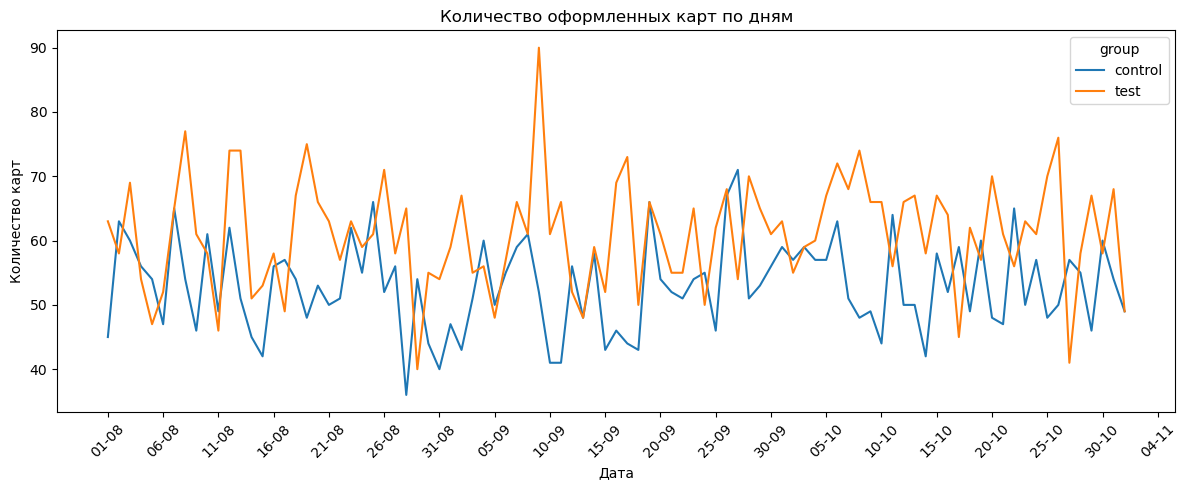

In [12]:
# строим график, отражающий количество оформленных карт по дням
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

daily_cards = df.groupby(['date', 'group'])['converted'].sum().reset_index()
daily_cards['date'] = pd.to_datetime(daily_cards['date'])

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_cards, x='date', y='converted', hue='group')
plt.title('Количество оформленных карт по дням')
plt.xlabel('Дата')
plt.ylabel('Количество карт')
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

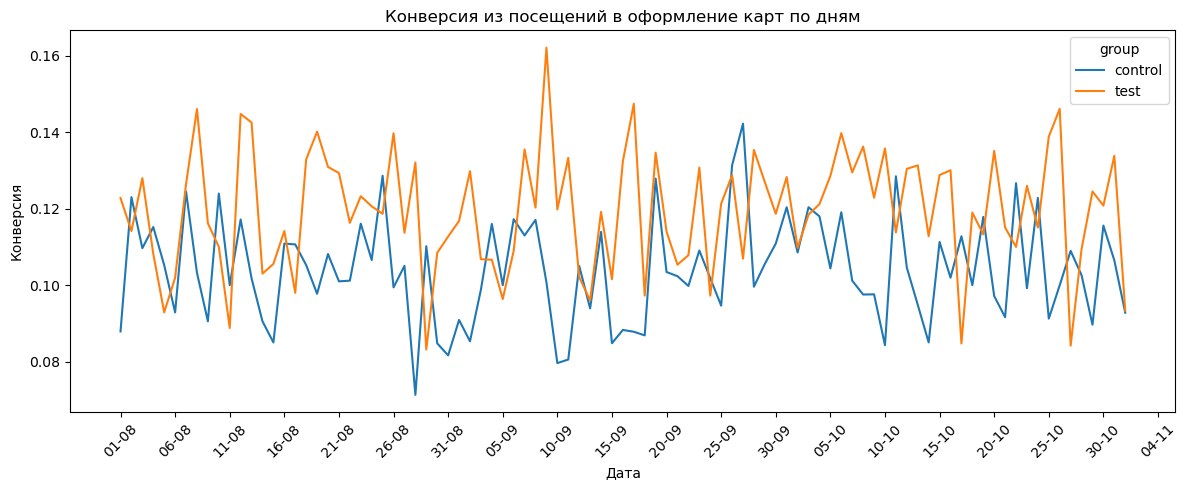

In [13]:
# строим график, отражающий конверсию из посещений в оформленние карт по дням
daily_conv = df.groupby(['date', 'group'])['converted'].mean().reset_index()
daily_conv['date'] = pd.to_datetime(daily_conv['date'])

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_conv, x='date', y='converted', hue='group')
plt.title('Конверсия из посещений в оформление карт по дням')
plt.xlabel('Дата')
plt.ylabel('Конверсия')
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

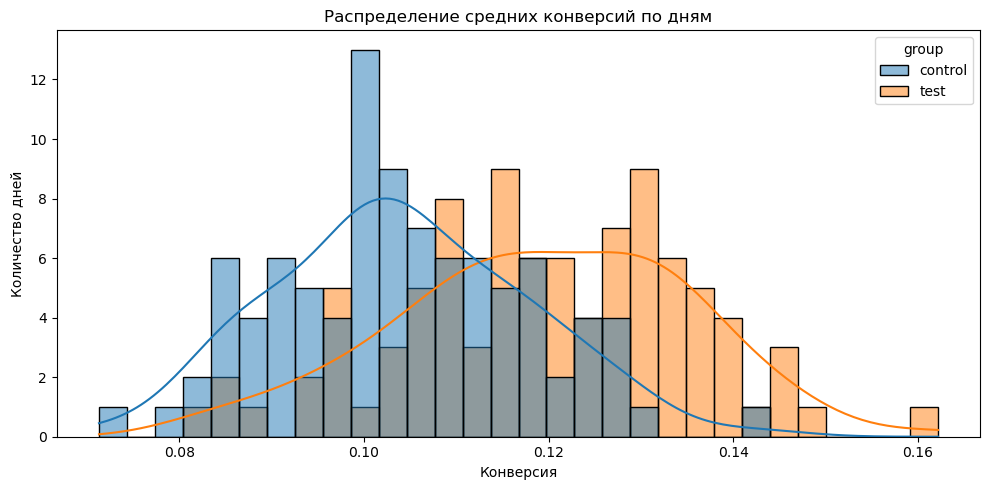

In [14]:
# строим распределения средних значений по дням в тесте и в контроле
plt.figure(figsize=(10, 5))
sns.histplot(data=daily_conv, x='converted', hue='group', kde=True, bins=30)
plt.title('Распределение средних конверсий по дням')
plt.xlabel('Конверсия')
plt.ylabel('Количество дней')
plt.tight_layout()
plt.show()

In [15]:
# используем статистический тест
conv_test = daily_conv[daily_conv['group'] == 'test']['converted']
conv_control = daily_conv[daily_conv['group'] == 'control']['converted']
stat, p_value = ttest_ind(conv_test, conv_control)
print('T-статистика:', round(stat, 4))
print('P-value:', round(p_value, 6))

T-статистика: 7.209
P-value: 0.0
